In [13]:
# install.packages("gtrendsR")
library(gtrendsR)
library(tidyverse)
library(lubridate)


  There is a binary version available but the source version is later:
         binary source needs_compilation
gtrendsR  1.5.1  1.5.2             FALSE

installing the source package ‘gtrendsR’



trying URL 'https://cran.rstudio.com/src/contrib/gtrendsR_1.5.2.tar.gz'
Content type 'application/x-gzip' length 1587952 bytes (1.5 MB)
downloaded 1.5 MB



* installing *source* package 'gtrendsR' ...
** package 'gtrendsR' successfully unpacked and MD5 sums checked
** using staged installation
** R
** data
*** moving datasets to lazyload DB
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (gtrendsR)



The downloaded source packages are in
	‘C:\Users\Saad.Khalid\AppData\Local\Temp\RtmpQJbSKf\downloaded_packages’


── Attaching core tidyverse packages ─────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ───────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning messages:
1: package ‘tidyverse’ was built under R version 4.3.3 
2: package ‘tidyr’ was built under R version 4.3.3 
3: package ‘dplyr’ was built under R version 4.3.3 
4: package ‘lubridate’ was built under R version 4.3.3 


In [5]:
# ==========================================
# 0. CONFIGURATION & LOAD DATA
# ==========================================
df_ads <- read_csv("C:/Users/Saad.Khalid/Documents/destify_robyn.csv") %>%
  mutate(date = as.Date(date))

start_date <- min(df_ads$date)
end_date <- max(df_ads$date)

# Base calendar grid
date_sequence <- tibble(date = seq(start_date, end_date, by = "day"))

Rows: 1274 Columns: 22
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl  (21): total_users, total_sessions, users_stage_1_lead, users_stage_2_mql, users_stage_3_schedu...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
# ==========================================
# 2. FETCH DESTINATION WEDDING INTENT & BRAND HEALTH
# ==========================================
print("Fetching Wedding Intent and Destify Brand Health...")

# Category keyword: "destination wedding" | Brand proxy: "Destify"
gtrends_raw <- gtrends(
  keyword = c("destination wedding", "Destify","destify"), 
  geo = "US", 
  time = paste(start_date, end_date, sep = " ")
)

str(gtrends_raw)

[1] "Fetching Wedding Intent and Destify Brand Health..."
List of 7
 $ interest_over_time :'data.frame':	549 obs. of  7 variables:
  ..$ date    : POSIXct[1:549], format: "2023-01-01" "2023-01-08" "2023-01-15" ...
  ..$ hits    : chr [1:549] "8" "8" "8" "11" ...
  ..$ keyword : chr [1:549] "destination wedding" "destination wedding" "destination wedding" "destination wedding" ...
  ..$ geo     : chr [1:549] "US" "US" "US" "US" ...
  ..$ time    : chr [1:549] "2023-01-02 2026-06-29" "2023-01-02 2026-06-29" "2023-01-02 2026-06-29" "2023-01-02 2026-06-29" ...
  ..$ gprop   : chr [1:549] "web" "web" "web" "web" ...
  ..$ category: int [1:549] 0 0 0 0 0 0 0 0 0 0 ...
 $ interest_by_country: NULL
 $ interest_by_region :'data.frame':	153 obs. of  5 variables:
  ..$ location: chr [1:153] "District of Columbia" "New York" "Mississippi" "Delaware" ...
  ..$ hits    : chr [1:153] "100" "70" "66" "65" ...
  ..$ keyword : chr [1:153] "destination wedding" "destination wedding" "destination wedding"

In [7]:
df_trends_raw <- gtrends_raw$interest_over_time %>%
  # 1. Clean data and standardize keywords to lowercase
  mutate(
    date = as.Date(date), 
    hits = as.numeric(if_else(hits == "<1", "0.5", as.character(hits))), 
    keyword = tolower(keyword)
  ) %>%
  # 2. Group by date and keyword to catch the duplicate "destify" rows
  group_by(date, keyword) %>%
  # 3. Collapse the duplicates into a single row using max() or mean()
  summarise(hits = max(hits, na.rm = TRUE), .groups = "drop") %>%
  select(date, keyword, hits)

str(df_trends_raw)

tibble [366 × 3] (S3: tbl_df/tbl/data.frame)
 $ date   : Date[1:366], format: "2023-01-01" "2023-01-01" "2023-01-08" ...
 $ keyword: chr [1:366] "destify" "destination wedding" "destify" "destination wedding" ...
 $ hits   : num [1:366] 0.5 8 0.5 8 0.5 8 0.5 11 0.5 7 ...


In [8]:
df_trends_wide <- df_trends_raw %>%
  pivot_wider(names_from = keyword, values_from = hits, names_prefix = "google_trends_") %>%
  rename(
    engagement_season_trend = `google_trends_destination wedding`,
    # Note: Because of tolower(), your column prefix becomes lowercase "destify"
    brand_health_proxy      = google_trends_destify 
  )

  str(df_trends_wide)

tibble [183 × 3] (S3: tbl_df/tbl/data.frame)
 $ date                   : Date[1:183], format: "2023-01-01" "2023-01-08" "2023-01-15" ...
 $ brand_health_proxy     : num [1:183] 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0 0.5 ...
 $ engagement_season_trend: num [1:183] 8 8 8 11 7 7 6 7 7 6 ...


In [9]:
# Merge and smoothly interpolate weekly search scores to a daily grain
df_trends_daily <- date_sequence %>%
  left_join(df_trends_wide, by = "date") %>%
  arrange(date) %>%
  mutate(
    engagement_season_trend = approx(date, engagement_season_trend, xout = date)$y,
    brand_health_proxy      = approx(date, brand_health_proxy, xout = date)$y
  )

df_trends_daily <- df_trends_daily %>%
  mutate(
    # Specify which columns to replace NAs in, and what value to use
    engagement_season_trend = replace_na(engagement_season_trend, 0),
    brand_health_proxy      = replace_na(brand_health_proxy, 0)
  )

str(df_trends_daily)

tibble [1,275 × 3] (S3: tbl_df/tbl/data.frame)
 $ date                   : Date[1:1275], format: "2023-01-02" "2023-01-03" "2023-01-04" ...
 $ brand_health_proxy     : num [1:1275] 0 0 0 0 0 0 0.5 0.5 0.5 0.5 ...
 $ engagement_season_trend: num [1:1275] 0 0 0 0 0 0 8 8 8 8 ...


In [10]:
df_combined <- df_ads %>%
  # Ensure the date columns are the same data type (Date format)
  mutate(date = as.Date(date)) %>%
  left_join(df_trends_daily, by = "date")
# write.csv(df_combined,"destify_r4_robyn.csv")

str(df_combined)

tibble [1,274 × 24] (S3: tbl_df/tbl/data.frame)
 $ date                    : Date[1:1274], format: "2026-06-29" "2026-06-28" "2026-06-27" ...
 $ total_users             : num [1:1274] 6294 5885 5228 5149 5513 ...
 $ total_sessions          : num [1:1274] 6234 5849 5183 5174 5492 ...
 $ users_stage_1_lead      : num [1:1274] 148 156 118 109 119 133 144 149 130 108 ...
 $ users_stage_2_mql       : num [1:1274] 82 105 69 72 69 94 92 94 86 66 ...
 $ users_stage_3_scheduled : num [1:1274] 44 31 25 29 27 27 48 43 28 30 ...
 $ users_stage_3b_completed: num [1:1274] 96 45 40 60 89 75 91 109 36 50 ...
 $ users_stage_4_quote     : num [1:1274] 38 10 11 38 46 40 43 49 9 14 ...
 $ users_stage_5_deposit   : num [1:1274] 25 10 4 21 24 21 18 35 10 6 ...
 $ users_stage_6_converted : num [1:1274] 12 4 4 13 11 7 7 6 1 4 ...
 $ google_spend            : num [1:1274] 3868 3982 3617 3273 4067 ...
 $ facebook_spend          : num [1:1274] 1514 1642 1605 1428 1318 ...
 $ bing_spend              : num [1:1274

In [8]:
df_combined = read.csv("C:/Users/Saad.Khalid/Documents/destify_r4_robyn.csv")

In [5]:
library(Robyn)
library(reticulate)

Warning message:
package ‘reticulate’ was built under R version 4.3.3 


In [9]:
use_virtualenv("r-reticulate", required = TRUE)
# py_install("nevergrad", pip = TRUE)


In [13]:
weekly= df_combined
weekly$date = as.Date(weekly$date)

In [17]:
str(weekly)

spc_tbl_ [1,274 × 25] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ ...1                    : num [1:1274] 1 2 3 4 5 6 7 8 9 10 ...
 $ date                    : Date[1:1274], format: "2026-06-29" "2026-06-28" "2026-06-27" ...
 $ total_users             : num [1:1274] 6294 5885 5228 5149 5513 ...
 $ total_sessions          : num [1:1274] 6234 5849 5183 5174 5492 ...
 $ users_stage_1_lead      : num [1:1274] 148 156 118 109 119 133 144 149 130 108 ...
 $ users_stage_2_mql       : num [1:1274] 82 105 69 72 69 94 92 94 86 66 ...
 $ users_stage_3_scheduled : num [1:1274] 44 31 25 29 27 27 48 43 28 30 ...
 $ users_stage_3b_completed: num [1:1274] 96 45 40 60 89 75 91 109 36 50 ...
 $ users_stage_4_quote     : num [1:1274] 38 10 11 38 46 40 43 49 9 14 ...
 $ users_stage_5_deposit   : num [1:1274] 25 10 4 21 24 21 18 35 10 6 ...
 $ users_stage_6_converted : num [1:1274] 12 4 4 13 11 7 7 6 1 4 ...
 $ google_spend            : num [1:1274] 3868 3982 3617 3273 4067 ...
 $ facebook_spend          : n

In [ ]:
# weekly[,-1]
summary(weekly)

      ...1             date             total_users     total_sessions  users_stage_1_lead
 Min.   :   1.0   Min.   :2023-01-02   Min.   :  1417   Min.   : 1497   Min.   :  0.00    
 1st Qu.: 319.2   1st Qu.:2023-11-16   1st Qu.:  2951   1st Qu.: 3229   1st Qu.:  0.00    
 Median : 637.5   Median :2024-09-29   Median :  3615   Median : 3841   Median :  0.00    
 Mean   : 637.5   Mean   :2024-09-29   Mean   :  4527   Mean   : 4438   Mean   : 55.51    
 3rd Qu.: 955.8   3rd Qu.:2025-08-14   3rd Qu.:  4727   3rd Qu.: 4894   3rd Qu.:115.00    
 Max.   :1274.0   Max.   :2026-06-29   Max.   :110246   Max.   :53951   Max.   :254.00    
                                                                                          
 users_stage_2_mql users_stage_3_scheduled users_stage_3b_completed users_stage_4_quote
 Min.   :  0.00    Min.   : 0.00           Min.   :  0.00           Min.   : 0.00      
 1st Qu.: 45.00    1st Qu.: 0.00           1st Qu.:  0.00           1st Qu.: 0.00      
 Median 

corrplot 0.92 loaded


Warning message:
package ‘corrplot’ was built under R version 4.3.2 


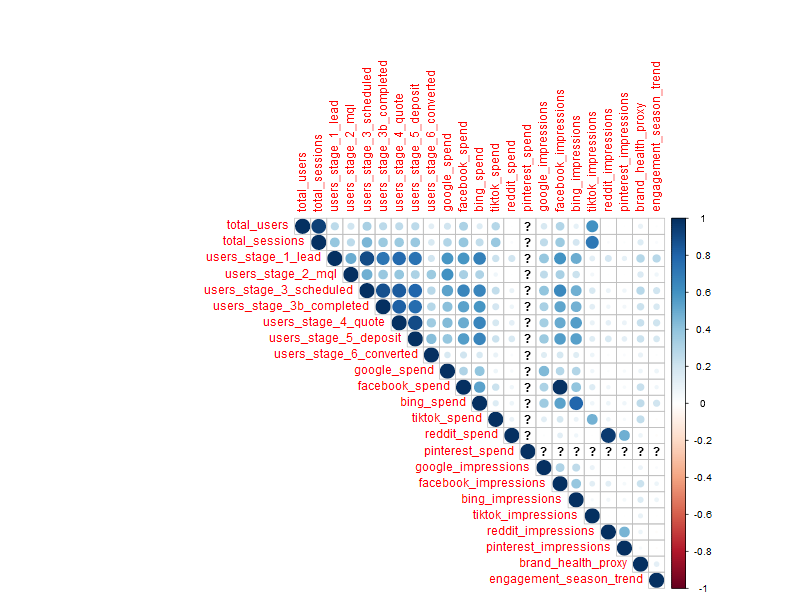

In [14]:
library(corrplot)
weekly %>% select_if(is.numeric) %>% cor() %>% corrplot(type = "upper")

Starting the Robyn moving forward


In [10]:
# Dependent variable
dep_var <- "users_stage_6_converted"
dep_var_type <- "conversion"

In [11]:
# Paid media spend and exposure (only real channels)

#Any media variables with a clear marketing spend falls into this category.


#This includes TV, Out of house advertising(eg. billboards), Facebook (facebook_I = impressions, facebook_S = spend), and search clicks. 


paid_media_spends <- c(
  "google_spend","facebook_spend","bing_spend",
  "tiktok_spend","reddit_spend","pinterest_spend"
)
paid_media_vars <- c(
  "google_impressions","facebook_impressions","bing_impressions",
  "tiktok_impressions","reddit_impressions","pinterest_impressions"
)


#We can specify context variables(context_vars) to Robyn such as competitor sales,
#price and promotional events, temperature, unemployment rate, CPI or COVID
context_vars <- c(
  "total_users","total_sessions","users_stage_1_lead",
  "users_stage_2_mql","users_stage_3_scheduled","users_stage_3b_completed",
  "users_stage_4_quote","users_stage_5_deposit",
  "brand_health_proxy","engagement_season_trend"
)

In [16]:
# Create InputCollect
InputCollect <- robyn_inputs(
  dt_input = weekly,  # replace 'gr' with your actual dataframe
  date_var = "date",
  dep_var = dep_var,
  dep_var_type = dep_var_type,
  paid_media_vars = paid_media_vars,
  paid_media_spends = paid_media_spends,
  # context_vars = context_vars,
  # context_signs = context_signs,
  factor_vars = NULL,
  # prophet_vars = c("trend","season"),
  prophet_vars = NULL,
  prophet_country = "US",
  adstock = "geometric",
  window_start = min(weekly$date),
  window_end = max(weekly$date),
  # hyperparameters = rhyperparameters
)

Input 'window_end' is larger than the latest dates available in input data. Automatically set to date: 2026-06-28


Warning messages:
1: In .next_date(dates_vec) :
  Unable to determine frequency to calculate next logical date. Returning last available date.
2: In .next_date(dates_vec) :
  Unable to determine frequency to calculate next logical date. Returning last available date.
3: In .next_date(dates_vec) :
  Unable to determine frequency to calculate next logical date. Returning last available date.


In [17]:
rhyperparameters = set_default_hyppar(
  adstock = InputCollect$adstock,
  all_media = InputCollect$all_media,
  list_default = list(
    alpha = c(0.5, 2.0),       # Cut down from 3 to prevent extreme, volatile curves
    gamma = c(0.2, 0.8),       # Cut out 0.01 and 1 to keep inflection points realistic
    theta = c(0.1, 0.5),       # Cut out 0 to 0.1 (no lag) and 0.5 to 0.8 (unrealistically long lag)
    shape = c(0, 10),          # Safely ignored by Geometric, but kept for default structure
    scale = c(0, 0.1),         # Safely ignored by Geometric, but kept for default structure
    train_size = c(0.5, 0.9)   # Keep as default if ts_validation is needed, otherwise ignored
  )
)

In [18]:
# Create InputCollect
InputCollect <- robyn_inputs(
  dt_input = weekly,  # replace 'gr' with your actual dataframe
  date_var = "date",
  dep_var = dep_var,
  dep_var_type = dep_var_type,
  paid_media_vars = paid_media_vars,
  paid_media_spends = paid_media_spends,
  context_vars = context_vars,
  # context_signs = context_signs,
  factor_vars = NULL,
  # prophet_vars = c("trend","season"),
  prophet_vars = c("trend", "season", "holiday"),
  # prophet_vars = NULL,
  prophet_country = "US",
  adstock = "geometric",
  window_start = "2020-01-01",
  window_end = "2026-09-19",
  hyperparameters = rhyperparameters
)

Input 'window_start' is smaller than the earliest date in input data. It's automatically set to the earliest date: 2023-01-02
Input 'window_end' is larger than the latest dates available in input data. Automatically set to date: 2026-06-28
>> Running feature engineering...
NOTE: potential improvement on splitting channels for better spend exposure fitting. Threshold (min.adj.R2) = 0.8 
  Check: InputCollect$ExposureCollect$plot_spend_exposure outputs
  Weak relationship for: "google_impressions", "bing_impressions", "tiktok_impressions" and their spend


Warning messages:
1: In .next_date(dates_vec) :
  Unable to determine frequency to calculate next logical date. Returning last available date.
2: In .next_date(dates_vec) :
  Unable to determine frequency to calculate next logical date. Returning last available date.
3: In .next_date(dates_vec) :
  Unable to determine frequency to calculate next logical date. Returning last available date.
4: In prophet_decomp(dt_transform, dt_holidays = InputCollect$dt_holidays,  :
  Currently, there's a known issue with prophet that may crash this use case.
 Read more here: https://github.com/facebookexperimental/Robyn/issues/472


In [ ]:
# Pure dataframe me jahan bhi missing ya NA value hy, wahan 0 daldo
# weekly[is.na(weekly)] <- 0


In [26]:
# Run Robyn using 4 cores
OutputModels <- robyn_run(
  InputCollect = InputCollect,
  seed = 1234,
  cores = 4,
  trials = 5,
  iterations = 3000,
  ts_validation = TRUE, # 3-way-split time series for NRMSE validation.
  add_penalty_factor = FALSE # Experimental feature. Use with caution.
)

Input data has 1274 days in total: 2023-01-02 to 2026-06-28
Initial model is built on rolling window of 1273 day: 2023-01-02 to 2026-06-28
Time-series validation with train_size range of 50%-90% of the data...
Using geometric adstocking with 20 hyperparameters (20 to iterate + 0 fixed) on 4 cores
>>> Starting 5 trials with 3000 iterations each using TwoPointsDE nevergrad algorithm...
  Running trial 1 of 5
  |=============================================================================================| 100%
  Finished in 12.55 mins
This trial contains 317 iterations with all media coefficient = 0. Please reconsider your media variable choice if the pareto choices are unreasonable. 
   Recommendations: 
1. Increase hyperparameter ranges for 0-coef channels to give Robyn more freedom 
2. Split media into sub-channels, and/or aggregate similar channels, and/or introduce other media 
3. Increase trials to get more samples
  Running trial 2 of 5
  |==========================================

Warning messages:
1: In .next_date(InputCollect$dt_mod$ds) :
  Unable to determine frequency to calculate next logical date. Returning last available date.
2: package ‘doRNG’ was built under R version 4.3.3 
3: package ‘foreach’ was built under R version 4.3.3 
4: package ‘rngtools’ was built under R version 4.3.3 


In [27]:
# Save the full trained model state locally
saveRDS(OutputModels, file = "robyn_converged_model.rds")


In [28]:
getwd()

[1] "c:/Users/Saad.Khalid/Downloads/jetfuel/Sprout"

In [24]:
OutputCollected  =robyn_outputs(
  InputCollect,
  OutputModels,
  cores = 1,
  pareto_fronts = 1,
  calibration_constraint = 0.1,
  plot_folder = "c:/Users/Saad.Khalid/Downloads/jetfuel/Sprout",
  plot_folder_sub = "c:/Users/Saad.Khalid/Downloads/jetfuel/Sprout",
  plot_pareto = TRUE,
  csv_out = "pareto",
  clusters = TRUE,
  select_model = "clusters",
  ui = TRUE,
  export = TRUE,
  all_sol_json = TRUE,
  quiet = FALSE,
  refresh = FALSE
)

>>> Running Pareto calculations for 15000 models on 1 front...


Warning message:
In file(con, "w") :
  cannot open file 'C:\Users\SAAD~1.KHA\AppData\Local\Temp\RtmpWetEzH\file7cf4504c8e0': No such file or directory


: Error in `file()`:
! cannot open the connection

In [23]:
# Create the directory if it doesn't exist
if (!dir.exists("C:/Rtemp")) dir.create("C:/Rtemp")

# Force R to use it for temporary files
Sys.setenv(TMPDIR = "C:/Rtemp")
Sys.setenv(TMP = "C:/Rtemp")
Sys.setenv(TEMP = "C:/Rtemp")


In [26]:
# 1. Keep this safety line active
OutputModels$cores <- 1

# 2. Run the corrected outputs code
OutputCollected = robyn_outputs(
  InputCollect,
  OutputModels,
  cores = 1,
  pareto_fronts = 1,
  calibration_constraint = 0.1,
  # Base directory
  plot_folder = "c:/Users/Saad.Khalid/Downloads/jetfuel/Sprout", 
  # FIX: Set this to a simple name string, NOT a full path
  plot_folder_sub = "results", 
  plot_pareto = TRUE,
  csv_out = "pareto",
  clusters = TRUE,
  select_model = "clusters",
  ui = TRUE,
  export = TRUE,
  all_sol_json = TRUE,
  quiet = FALSE,
  refresh = FALSE
)


>>> Running Pareto calculations for 15000 models on 1 front...
>>> Calculating response curves for all models' media variables (144)...
  |======================================================================| 100%
>> Pareto-Front: 1 [24 models]
 00:00:13 [=========================================] 100% | 24                      00:00:03 [============                             ] 29.2% | 7                      
Creating directory for outputs: c:/Users/Saad.Khalid/Downloads/jetfuel/Sprout/results/
>>> Calculating clusters for model selection using Pareto fronts...
>> Auto selected k = 7 (clusters) based on minimum WSS variance of 6%
>>> Collecting 24 pareto-optimum results into: c:/Users/Saad.Khalid/Downloads/jetfuel/Sprout/results/
>> Exporting general plots into directory...
>> Exporting pareto results as CSVs into directory...
>>> Exporting pareto one-pagers into directory...
>> Generating only cluster results one-pagers (7)...
>> Plotting 7 selected models on 1 cores...
  |       

Warning messages:
1: In confidence_calcs(xDecompAgg, cls, all_paid, dep_var_type, k,  :
  Cluster 1 does not contain enough models to calculate CI
2: In confidence_calcs(xDecompAgg, cls, all_paid, dep_var_type, k,  :
  Cluster 2 does not contain enough models to calculate CI
3: In confidence_calcs(xDecompAgg, cls, all_paid, dep_var_type, k,  :
  Cluster 4 does not contain enough models to calculate CI
4: In confidence_calcs(xDecompAgg, cls, all_paid, dep_var_type, k,  :
  Cluster 6 does not contain enough models to calculate CI
5: Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the Robyn package.
  Please report the issue at
  <]8;;https://github.com/facebookexperimental/Robyn/issueshttps://github.com/facebookexperimental/Robyn/issues]8;;>.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see 

In [2]:
getwd()

[1] "c:/Users/Saad.Khalid/Downloads"

In [3]:
# Load it back instantly without any training lag
OutputModels <- readRDS("c:/Users/Saad.Khalid/Downloads/jetfuel/Sprout/robyn_converged_model.rds")

# Verify the object loaded correctly
str(OutputModels, max.level = 1)


List of 19
 $ trial1            :List of 4
 $ trial2            :List of 4
 $ trial3            :List of 4
 $ trial4            :List of 4
 $ trial5            :List of 4
 $ train_timestamp   : POSIXct[1:1], format: "2026-07-05 18:25:02"
 $ cores             : num 4
 $ iterations        : num 3000
 $ trials            : num 5
 $ intercept         : logi TRUE
 $ intercept_sign    : chr "non_negative"
 $ nevergrad_algo    : chr "TwoPointsDE"
 $ ts_validation     : logi TRUE
 $ add_penalty_factor: logi FALSE
 $ hyper_updated     :List of 20
 $ hyper_fixed       : logi FALSE
  ..- attr(*, "hypParamSamName")= chr [1:20] "bing_impressions_alphas" "bing_impressions_gammas" "bing_impressions_thetas" "facebook_impressions_alphas" ...
 $ convergence       :List of 4
  ..- attr(*, "sd_qtref")= num 3
  ..- attr(*, "med_lowb")= num 2
 $ ts_validation_plot:A patchwork composed of 2 patches
- Autotagging is turned off
- Guides are collected

Layout:
2 patch areas, spanning 2 columns and 1 rows

    t

In [1]:
library(dplyr)

# 1. Pull all evaluated model solutions
all_models <- OutputCollected$allSolutions

# 2. Filter and rank for your optimal models
best_models <- all_models %>%
  # Focus primarily on the top Pareto fronts (Front 1 is best)
  filter(robynPareto == 1) %>% 
  # Arrange by highest Adjusted R2, lowest NRMSE, and lowest DECOMP.RSSD
  arrange(desc(rsq_train), nrmse, decomp.rssd) %>%
  # Select the key metrics for easy viewing
  select(solID, rsq_train, nrmse, decomp.rssd, robynPareto)

# 3. Print the top 10 best-performing models to your console
print("--- Top 10 Optimal Models (Pareto Front 1) ---")
print(head(best_models, 10))



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Warning message:
package ‘dplyr’ was built under R version 4.3.3 


: Error:
! object 'OutputCollected' not found

In [4]:
robyn_onepagers(
  InputCollect,
  OutputCollect,
  select_model = NULL,
  quiet = FALSE,
  export = TRUE,
  plot_folder = OutputCollect$plot_folder,
  baseline_level = 0,
  # ...
)

: Error in `robyn_onepagers()`:
! could not find function "robyn_onepagers"